### Changes:

1- We trained the model on 5 gauge stations belonging to the same cluster to check if the generations will have a more realistic distribution and/or scale

2- Changed the training steps to 10,000 instead of 20,000 as no improvement was witnessed from 10,000 epochs onwards

3- Changed some of the weights of the losses to monitor the changes during training: cell 20, 31 and 32.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from pathlib import Path
from tqdm import tqdm

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GRU, Dense, RNN, GRUCell, Input
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.utils import plot_model

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Import & Isolation

In [3]:
df= pd.read_csv("df_data.csv").dropna()

df

,Unnamed: 0,time_UTC,observed_data,forecast_data,offset,x,y,station_id,time_UTC_dt
1,0.0,9/25/2022 1:00,2.560,2.315,-0.245,-73.710194,40.866222,1302250.0,0.0
3,1.0,9/25/2022 2:00,2.540,3.625,1.085,-73.710194,40.866222,1302250.0,60.0
5,2.0,9/25/2022 3:00,2.940,3.959,1.019,-73.710194,40.866222,1302250.0,120.0
7,3.0,9/25/2022 4:00,3.270,3.747,0.477,-73.710194,40.866222,1302250.0,180.0
9,4.0,9/25/2022 5:00,2.970,2.483,-0.487,-73.710194,40.866222,1302250.0,240.0
...,...,...,...,...,...,...,...,...,...
83519,41759.0,10/1/2022 19:00,1.060,0.452,-0.608,-67.938500,18.089910,9759938.0,9720.0
83521,41760.0,10/1/2022 20:00,1.063,0.410,-0.653,-67.938500,18.089910,9759938.0,9780.0
83523,41761.0,10/1/2022 21:00,1.024,0.360,-0.664,-67.938500,18.089910,9759938.0,9840.0
83525,41762.0,10/1/2022 22:00,0.981,0.293,-0.688,-67.938500,18.089910,9759938.0,9900.0


In [4]:
df = df[df['station_id'].isin([85750.0, 292800000000000.0, 8761305.0, 8761724.0, 8761927.0, 8761955.0, 300722000000000.0,
                               85670.0, 7380249.0, 73745275.0, 7374527.0, 7374526.0, 73745258.0, 73745257.0, 
                               301001000000000.0, 291929000000000.0, 85575.0, 1545.0, 8760721.0, 8747437.0, 1850.0, 
                               85420.0, 1670.0, 8760922.0])]

df.drop(['Unnamed: 0','forecast_data','observed_data','time_UTC_dt'], axis=1, inplace= True)

df

,time_UTC,offset,x,y,station_id
6307,9/25/2022 1:00,-0.384,-89.246500,29.1338,1545.0
6309,9/25/2022 2:00,-0.410,-89.246500,29.1338,1545.0
6311,9/25/2022 3:00,-0.439,-89.246500,29.1338,1545.0
6313,9/25/2022 4:00,-0.473,-89.246500,29.1338,1545.0
6315,9/25/2022 5:00,-0.428,-89.246500,29.1338,1545.0
...,...,...,...,...,...
68611,10/1/2022 19:00,4.546,-90.137257,29.9329,8761955.0
68613,10/1/2022 20:00,4.557,-90.137257,29.9329,8761955.0
68615,10/1/2022 21:00,4.651,-90.137257,29.9329,8761955.0
68617,10/1/2022 22:00,4.621,-90.137257,29.9329,8761955.0


In [5]:
pivot_df = df.pivot_table(values='offset', index='time_UTC', columns='station_id', aggfunc='first')
df= pivot_df

df

station_id,1.545000e+03,1.670000e+03,1.850000e+03,8.542000e+04,8.557500e+04,8.567000e+04,8.575000e+04,7.374526e+06,7.374527e+06,7.380249e+06,...,8.761724e+06,8.761927e+06,8.761955e+06,7.374526e+07,7.374526e+07,7.374528e+07,2.919290e+14,2.928000e+14,3.007220e+14,3.010010e+14
time_UTC,,,,,,,,,,,,,,,,,,,,,
10/1/2022 0:00,-0.036,-0.074,-0.153,-0.646,-0.480,-0.725,0.125,-0.203,0.130,-0.977,...,-0.032,-0.703,4.467,0.611,-0.410,0.836,-0.051,-0.292,0.210,-0.130
10/1/2022 10:00,-0.109,-0.246,-0.344,-0.448,-0.351,-0.730,-0.428,-0.042,0.399,-1.309,...,-0.446,-0.721,4.218,-0.088,-0.057,0.762,-0.267,-0.520,0.341,-0.200
10/1/2022 11:00,-0.133,-0.333,-0.339,-0.445,-0.409,-0.660,-0.352,-0.042,0.365,-1.311,...,-0.533,-0.679,4.250,-0.116,-0.082,0.683,-0.267,-0.451,0.338,-0.216
10/1/2022 12:00,-0.193,-0.377,-0.336,-0.412,-0.438,-0.675,-0.311,-0.070,0.383,-1.354,...,-0.546,-0.721,4.271,-0.101,-0.024,0.539,-0.248,-0.409,0.306,-0.229
10/1/2022 13:00,-0.224,-0.369,-0.364,-0.432,-0.388,-0.706,-0.252,0.007,0.475,-1.259,...,-0.544,-0.721,4.316,-0.022,-0.011,0.550,-0.144,-0.348,0.487,-0.258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9/30/2022 5:00,-0.165,-0.199,-0.248,-0.853,-0.519,-0.840,-0.139,-0.604,-0.527,-1.430,...,-0.233,-1.015,4.007,-0.023,-1.109,0.333,-0.224,-0.578,0.248,-0.277
9/30/2022 6:00,-0.211,-0.265,-0.286,-0.802,-0.467,-0.789,-0.236,-0.535,-0.465,-1.258,...,-0.313,-0.844,3.979,-0.143,-0.958,0.408,-0.178,-0.581,0.365,-0.335
9/30/2022 7:00,-0.276,-0.308,-0.302,-0.764,-0.410,-0.808,-0.374,-0.562,-0.349,-1.401,...,-0.366,-0.869,3.942,-0.214,-0.909,0.391,-0.310,-0.564,0.154,-0.437


In [6]:
# coords_df = df[['station_id', 'x', 'y']].drop_duplicates()
# coords_df

### Plot Series

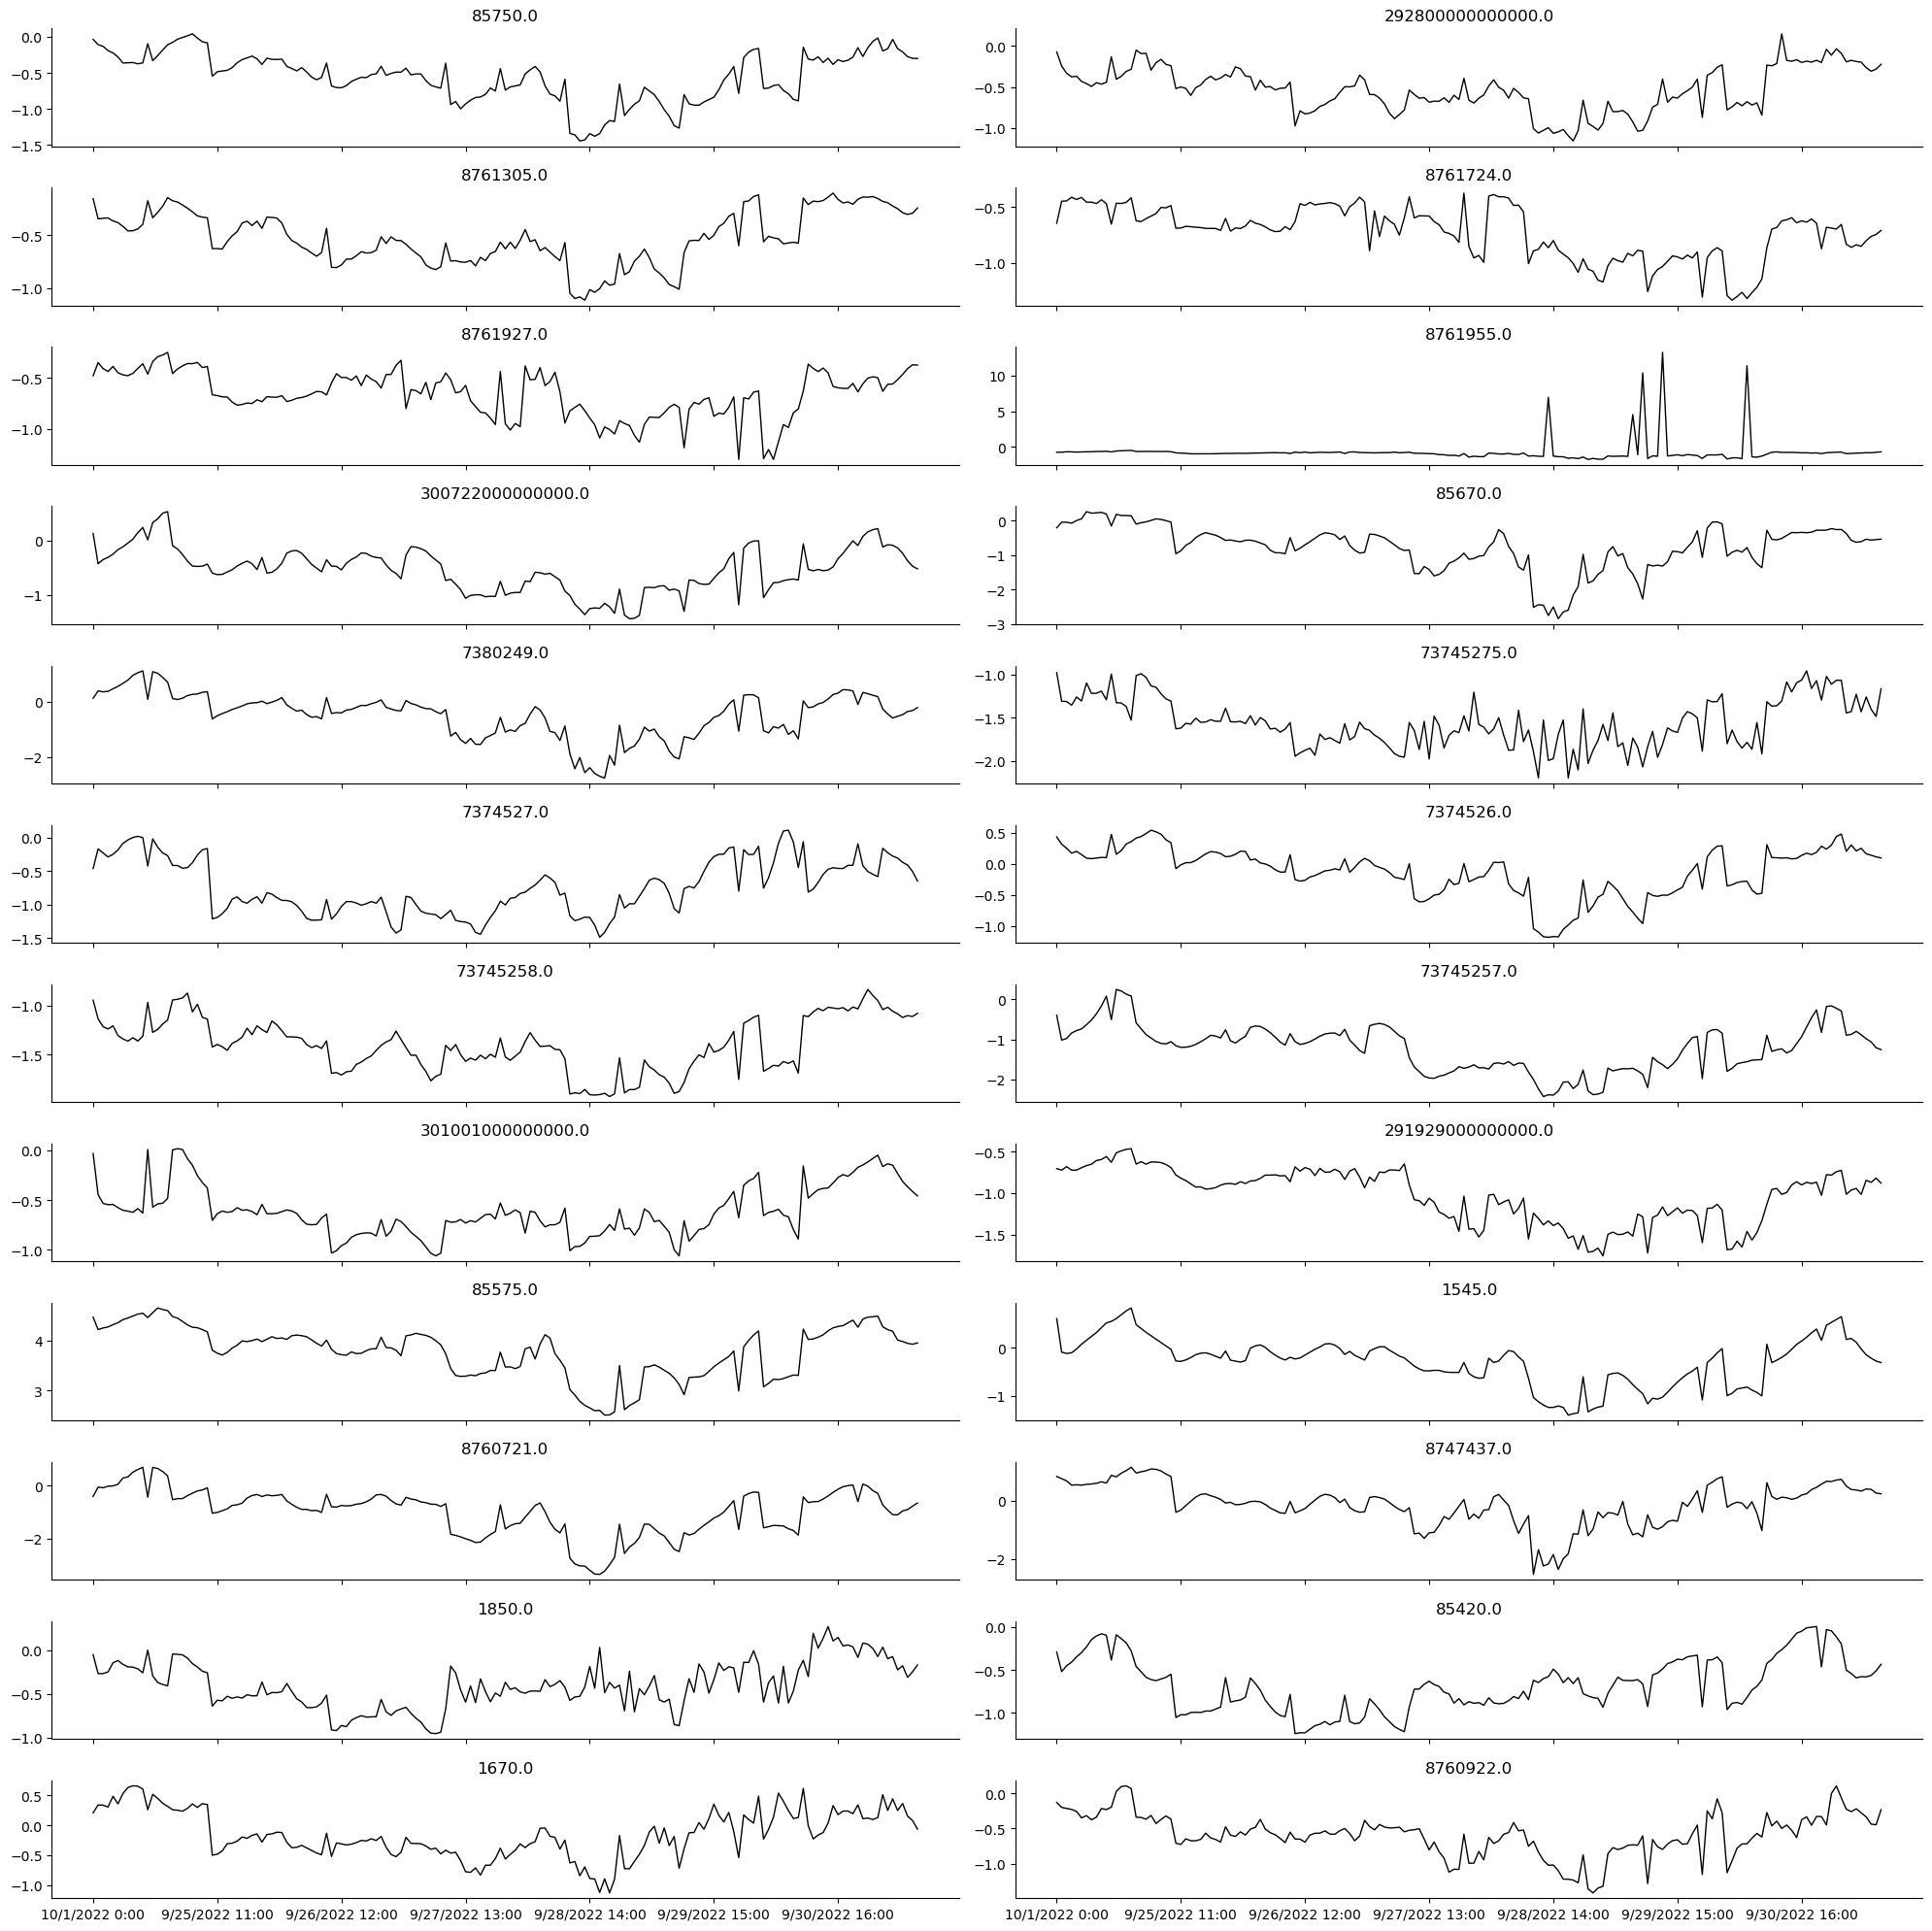

In [7]:
axes = df.plot(subplots=True,
               figsize=(20,20),
               layout=(12, 2),
               legend=False,
               rot=0,
               lw=1, 
               color='k')

titles = [85750.0, 292800000000000.0, 8761305.0, 8761724.0, 8761927.0, 8761955.0, 300722000000000.0,
                85670.0, 7380249.0, 73745275.0, 7374527.0, 7374526.0, 73745258.0, 73745257.0, 
                301001000000000.0, 291929000000000.0, 85575.0, 1545.0, 8760721.0, 8747437.0, 1850.0, 
                85420.0, 1670.0, 8760922.0]

for ax, title in zip(axes.flatten(), titles):
    ax.set_title(title)
    ax.set_xlabel('')

plt.gcf().tight_layout()
sns.despine()
plt.show()

# Work Starts Here: Data Preprocessing

In [8]:
stations_to_keep= [85750.0, 292800000000000.0, 8761305.0, 8761955.0, 300722000000000.0,
                85670.0, 7380249.0, 7374527.0, 7374526.0, 73745258.0, 73745257.0, 
                301001000000000.0, 291929000000000.0]

In [9]:
df= pd.read_csv("df_data.csv").dropna()

df = df[df['station_id'].isin(stations_to_keep)]

df.drop(['Unnamed: 0','forecast_data','observed_data','time_UTC_dt'], axis=1, inplace= True)

pivot_df = df.pivot_table(values='offset', index='time_UTC', columns='station_id', aggfunc='first')
df= pivot_df

df

station_id,8.567000e+04,8.575000e+04,7.374526e+06,7.374527e+06,7.380249e+06,8.761305e+06,8.761955e+06,7.374526e+07,7.374526e+07,2.919290e+14,2.928000e+14,3.007220e+14,3.010010e+14
time_UTC,,,,,,,,,,,,,
10/1/2022 0:00,-0.725,0.125,-0.203,0.130,-0.977,-0.400,4.467,0.611,-0.410,-0.051,-0.292,0.210,-0.130
10/1/2022 10:00,-0.730,-0.428,-0.042,0.399,-1.309,-1.021,4.218,-0.088,-0.057,-0.267,-0.520,0.341,-0.200
10/1/2022 11:00,-0.660,-0.352,-0.042,0.365,-1.311,-0.977,4.250,-0.116,-0.082,-0.267,-0.451,0.338,-0.216
10/1/2022 12:00,-0.675,-0.311,-0.070,0.383,-1.354,-0.842,4.271,-0.101,-0.024,-0.248,-0.409,0.306,-0.229
10/1/2022 13:00,-0.706,-0.252,0.007,0.475,-1.259,-0.780,4.316,-0.022,-0.011,-0.144,-0.348,0.487,-0.258
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9/30/2022 5:00,-0.840,-0.139,-0.604,-0.527,-1.430,-0.886,4.007,-0.023,-1.109,-0.224,-0.578,0.248,-0.277
9/30/2022 6:00,-0.789,-0.236,-0.535,-0.465,-1.258,-0.985,3.979,-0.143,-0.958,-0.178,-0.581,0.365,-0.335
9/30/2022 7:00,-0.808,-0.374,-0.562,-0.349,-1.401,-1.062,3.942,-0.214,-0.909,-0.310,-0.564,0.154,-0.437


# Data Preprocessing

### Normalize Data

In [10]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df).astype(np.float32)

print(scaled_data.shape)
print(scaled_data[1:5])

(167, 13)
[[0.06751337 0.51352733 0.90106004 0.8134156  0.716129   0.5261976
  0.79841715 0.5877075  0.8147327  0.5604575  0.57865167 0.82107025
  0.7988127 ]
 [0.07219251 0.5523226  0.90106004 0.8046775  0.7145161  0.54266465
  0.81331474 0.5751458  0.80857354 0.5604575  0.6340289  0.819398
  0.78825855]
 [0.07118984 0.57325166 0.8920655  0.8093035  0.6798387  0.59318864
  0.82309127 0.58187526 0.82286274 0.57598037 0.66773677 0.80156076
  0.77968335]
 [0.06911765 0.60336906 0.9168005  0.83294785 0.7564516  0.6163922
  0.844041   0.6173172  0.82606554 0.66094774 0.7166934  0.90245265
  0.7605541 ]]


### Create rolling window sequences

In [11]:
# Model Parameters

hidden_dim = 48
num_layers = 3

# Training and Preprocessing Parameters

seq_len = 48
n_seq = 13

batch_size = 32

In [12]:
data = []
for i in range(len(df) - seq_len):
    data.append(scaled_data[i:i + seq_len])

n_windows = len(data)

print(n_windows)

119


In [13]:
data[0]

array([[0.06784759, 0.7958142 , 0.84934145, 0.74428165, 0.983871  ,
        0.7586078 , 0.91433895, 0.901301  , 0.72776544, 0.7369281 ,
        0.7616372 , 0.7480491 , 0.8449868 ],
       [0.06751337, 0.51352733, 0.90106004, 0.8134156 , 0.716129  ,
        0.5261976 , 0.79841715, 0.5877075 , 0.8147327 , 0.5604575 ,
        0.57865167, 0.82107025, 0.7988127 ],
       [0.07219251, 0.5523226 , 0.90106004, 0.8046775 , 0.7145161 ,
        0.54266465, 0.81331474, 0.5751458 , 0.80857354, 0.5604575 ,
        0.6340289 , 0.819398  , 0.78825855],
       [0.07118984, 0.57325166, 0.8920655 , 0.8093035 , 0.6798387 ,
        0.59318864, 0.82309127, 0.58187526, 0.82286274, 0.57598037,
        0.66773677, 0.80156076, 0.77968335],
       [0.06911765, 0.60336906, 0.9168005 , 0.83294785, 0.7564516 ,
        0.6163922 , 0.844041  , 0.6173172 , 0.82606554, 0.66094774,
        0.7166934 , 0.90245265, 0.7605541 ],
       [0.07092246, 0.64522713, 0.93286216, 0.8563351 , 0.71935487,
        0.63136226, 0.86266

### Create tf.data.Dataset

In [14]:
# This will allow us to iterate on the data during the training
# We shuffle the data and batch it

real_series = (tf.data.Dataset
               .from_tensor_slices(data)
               .shuffle(buffer_size=n_windows)
               .batch(batch_size))

real_series_iter = iter(real_series.repeat())

### Set up random series generator

In [15]:
# The "marke_random_data" creates the distribution from which the generator will draw samples
# It will also have an iterator that matches the shape of the input iterator

def make_random_data():
    while True:
        yield np.random.uniform(low=0, high=1, size=(seq_len, n_seq))
        
random_series = iter(tf.data.Dataset
                     .from_generator(make_random_data, output_types=tf.float32)
                     .batch(batch_size)
                     .repeat())

# TimeGAN Components

### Input Placeholders

In [16]:
X = Input(shape=[seq_len, n_seq], name='RealData') 
Z = Input(shape=[seq_len, n_seq], name='RandomData')

In [17]:
print(X.shape)

(None, 48, 13)


### RNN block generator

In [18]:
def make_rnn(n_layers, hidden_units, output_units, name):
    return Sequential([GRU(units=hidden_units,
                           return_sequences=True,
                           name=f'LSTM_{i + 1}') for i in range(n_layers)] +
                      [Dense(units=output_units,
                             activation='sigmoid',
                             name='OUT')], name=name)

embedder = make_rnn(n_layers=4, 
                    hidden_units=hidden_dim, 
                    output_units=hidden_dim, 
                    name='Embedder')
recovery = make_rnn(n_layers=4, 
                    hidden_units=hidden_dim, 
                    output_units=n_seq, 
                    name='Recovery')
generator = make_rnn(n_layers=4, 
                     hidden_units=hidden_dim, 
                     output_units=hidden_dim, 
                     name='Generator')
discriminator = make_rnn(n_layers=3, 
                         hidden_units=hidden_dim, 
                         output_units=1, 
                         name='Discriminator')
supervisor = make_rnn(n_layers=3, 
                      hidden_units=hidden_dim, 
                      output_units=hidden_dim, 
                      name='Supervisor')

# TimeGAN Training

In [19]:
# Number of Epochs
phase1_train_steps = 5000
phase2_train_steps = phase1_train_steps

train_steps = 10000 # Changed it to 10k instead of 20k as no major improvement was witnessed in the latter half of the training

mse = MeanSquaredError()
bce = BinaryCrossentropy()

## Phase 1: Autoencoder
### Model

In [20]:
# Define the AutoEncoder Model: Consisting of the Embedder and Recovery

H = embedder(X)
X_tilde = recovery(H)

autoencoder_optimizer = Adam()

autoencoder = Model(inputs=X,
                    outputs=X_tilde,
                    name='Autoencoder')

autoencoder.summary()

Model: "Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RealData (InputLayer)       [(None, 48, 13)]          0         
                                                                 
 Embedder (Sequential)       (None, 48, 48)            53760     
                                                                 
 Recovery (Sequential)       (None, 48, 13)            57085     
                                                                 
Total params: 110,845
Trainable params: 110,845
Non-trainable params: 0
_________________________________________________________________


### Training

In [21]:
########################################################
# Weight of the embedding loss

eloss_weight = 10 # tried it with 20 to check if the scale difference will get smaller

########################################################

@tf.function
def train_autoencoder_init(x):
    with tf.GradientTape() as tape:
        x_tilde = autoencoder(x)
        
        embedding_loss_t0 = mse(x, x_tilde)
        e_loss_0 = eloss_weight * tf.sqrt(embedding_loss_t0)
        
    # Apply Gradients for: Embedder + Recovery
    var_list = embedder.trainable_variables + recovery.trainable_variables
    gradients = tape.gradient(e_loss_0, var_list)
    autoencoder_optimizer.apply_gradients(zip(gradients, var_list))
    
    return tf.sqrt(embedding_loss_t0)

autoencoder_training_history = []

for step in tqdm(range(phase1_train_steps)):
    X_ = next(real_series_iter)
    step_e_loss_t0 = train_autoencoder_init(X_)
    
    if step % 100 == 0:  
        autoencoder_training_history.append(step_e_loss_t0.numpy())

100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [06:05<00:00, 13.68it/s]


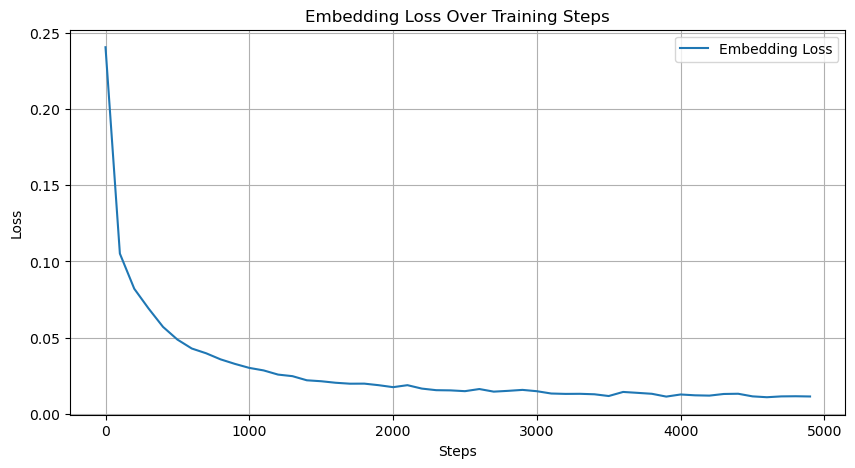

In [22]:
# TRIAL VISUALIZATION

plt.figure(figsize=(10, 5))
plt.plot(range(0, len(autoencoder_training_history) * 100, 100), autoencoder_training_history, label='Embedding Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Embedding Loss Over Training Steps')
plt.legend()
plt.grid(True)
plt.show()

## Phase 2: Supervised training

In [23]:
supervisor_optimizer = Adam()

@tf.function
def train_supervisor(x):
    with tf.GradientTape() as tape:
        h = embedder(x)
        h_hat_supervised = supervisor(h)
        
        g_loss_s = mse(h[:, 1:, :], h_hat_supervised[:, :-1, :])

    # Apply Gradients for: Supervisor       
    var_list = supervisor.trainable_variables
    gradients = tape.gradient(g_loss_s, var_list)
    supervisor_optimizer.apply_gradients(zip(gradients, var_list))
    
    return g_loss_s

supervised_training_history= []

for step in tqdm(range(phase2_train_steps)):
    X_ = next(real_series_iter)
    step_g_loss_s = train_supervisor(X_)
    
    if step % 100 == 0:  
        supervised_training_history.append(step_g_loss_s.numpy())

100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:32<00:00, 23.50it/s]


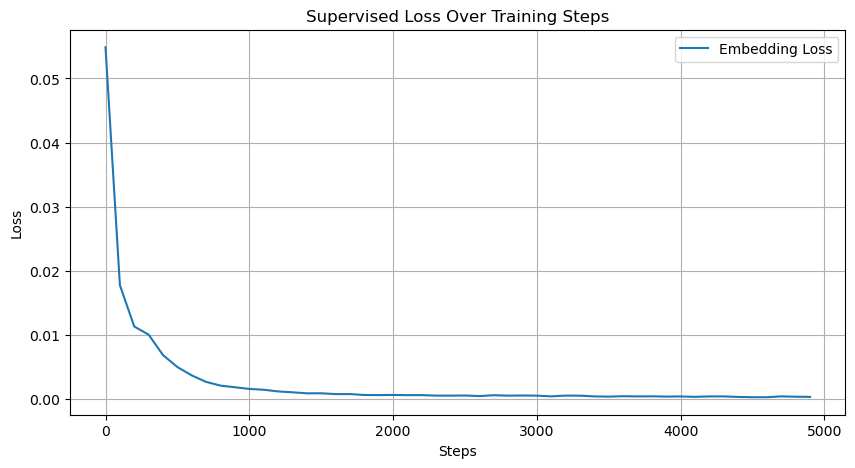

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(supervised_training_history) * 100, 100), supervised_training_history, label='Embedding Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Supervised Loss Over Training Steps')
plt.legend()
plt.grid(True)
plt.show()

# Joint Training

### Generator - Discriminator Models

In [25]:
# Adversarial Unsupervised Model (Supervisor & Discriminator)

E_hat = generator(Z)
H_hat = supervisor(E_hat)
Y_fake = discriminator(H_hat)

adversarial_supervised = Model(inputs=Z,
                               outputs=Y_fake,
                               name='AdversarialNetSupervised')

adversarial_supervised.summary()

Model: "AdversarialNetSupervised"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RandomData (InputLayer)     [(None, 48, 13)]          0         
                                                                 
 Generator (Sequential)      (None, 48, 48)            53760     
                                                                 
 Supervisor (Sequential)     (None, 48, 48)            44688     
                                                                 
 Discriminator (Sequential)  (None, 48, 1)             42385     
                                                                 
Total params: 140,833
Trainable params: 140,833
Non-trainable params: 0
_________________________________________________________________


In [26]:
# Adversarial Supervised Model (Generator & Discriminator)
Y_fake_e = discriminator(E_hat)

adversarial_emb = Model(inputs=Z,
                    outputs=Y_fake_e,
                    name='AdversarialNet')

adversarial_emb.summary()

Model: "AdversarialNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RandomData (InputLayer)     [(None, 48, 13)]          0         
                                                                 
 Generator (Sequential)      (None, 48, 48)            53760     
                                                                 
 Discriminator (Sequential)  (None, 48, 1)             42385     
                                                                 
Total params: 96,145
Trainable params: 96,145
Non-trainable params: 0
_________________________________________________________________


In [27]:
# Synthetic Data Generator (Generator - Supervisor - Recovery)

X_hat = recovery(H_hat)
synthetic_data = Model(inputs=Z,
                       outputs=X_hat,
                       name='SyntheticData')

synthetic_data.summary()

Model: "SyntheticData"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RandomData (InputLayer)     [(None, 48, 13)]          0         
                                                                 
 Generator (Sequential)      (None, 48, 48)            53760     
                                                                 
 Supervisor (Sequential)     (None, 48, 48)            44688     
                                                                 
 Recovery (Sequential)       (None, 48, 13)            57085     
                                                                 
Total params: 155,533
Trainable params: 155,533
Non-trainable params: 0
_________________________________________________________________


In [28]:
# Real data Discriminator (Discriminator & Embedder)

Y_real = discriminator(H)
discriminator_model = Model(inputs=X,
                            outputs=Y_real,
                            name='DiscriminatorReal')

discriminator_model.summary()

Model: "DiscriminatorReal"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RealData (InputLayer)       [(None, 48, 13)]          0         
                                                                 
 Embedder (Sequential)       (None, 48, 48)            53760     
                                                                 
 Discriminator (Sequential)  (None, 48, 1)             42385     
                                                                 
Total params: 96,145
Trainable params: 96,145
Non-trainable params: 0
_________________________________________________________________


### Training Steps

In [29]:
generator_optimizer = Adam()
discriminator_optimizer = Adam()
embedding_optimizer = Adam()

In [30]:
# Loss function to monitor the distribution of the Generator's data

def get_generator_moment_loss(y_true, y_pred):
    
    y_true_mean, y_true_var = tf.nn.moments(x=y_true, axes=[0])
    y_pred_mean, y_pred_var = tf.nn.moments(x=y_pred, axes=[0])
    g_loss_mean = tf.reduce_mean(tf.abs(y_true_mean - y_pred_mean))
    g_loss_var = tf.reduce_mean(tf.abs(tf.sqrt(y_true_var + 1e-6) - tf.sqrt(y_pred_var + 1e-6)))
    
    return g_loss_mean + g_loss_var

In [31]:
# Weight for the unsupervised fake loss
gamma = 1

#############################################################

# discriminator loss: loss_real, loss_fake, loss_fake_e
@tf.function
def get_discriminator_loss(x, z):
    
    # real loss
    y_real = discriminator_model(x)
    discriminator_loss_real = bce(y_true=tf.ones_like(y_real),
                                  y_pred=y_real)
    
    # supervised fake loss
    y_fake = adversarial_supervised(z)
    discriminator_loss_fake = bce(y_true=tf.zeros_like(y_fake),
                                  y_pred=y_fake)
    
    # unsupervised fake loss
    y_fake_e = adversarial_emb(z)
    discriminator_loss_fake_e = bce(y_true=tf.zeros_like(y_fake_e),
                                    y_pred=y_fake_e)
    
    return (discriminator_loss_real +
            discriminator_loss_fake +
            gamma * discriminator_loss_fake_e)

In [32]:
### Generator Training Step

# Weights for generator losses
supervised_gen_loss_weight= 100 # Was 1 with all the generator's losses having similar weights, gave worse results in
                              # terms of distribution.

distribution_loss_weight = 1
##########################################################################

@tf.function
def train_generator(x, z):
    with tf.GradientTape() as tape:
        
        # adversarial semi-supervised loss (Generator + Supervisor)
        y_fake = adversarial_supervised(z)
        generator_loss_unsupervised = bce(y_true=tf.ones_like(y_fake),
                                          y_pred=y_fake)
        
        # adversarial unsupervised loss (Generator)
        y_fake_e = adversarial_emb(z)
        generator_loss_unsupervised_e = bce(y_true=tf.ones_like(y_fake_e),
                                            y_pred=y_fake_e)
        
        # adversarial supervised loss (Embedder + Supervisor)
        h = embedder(x)
        h_hat_supervised = supervisor(h)
        generator_loss_supervised = mse(h[:, 1:, :], h_hat_supervised[:, 1:, :])

        # distribution loss
        x_hat = synthetic_data(z)
        generator_moment_loss = get_generator_moment_loss(x, x_hat)

        generator_loss = (generator_loss_unsupervised +
                          generator_loss_unsupervised_e +
                          supervised_gen_loss_weight * tf.sqrt(generator_loss_supervised) +
                          distribution_loss_weight * generator_moment_loss)
    
    # Apply Gradients for: Generator + Supervisor
    var_list = generator.trainable_variables + supervisor.trainable_variables
    gradients = tape.gradient(generator_loss, var_list)
    generator_optimizer.apply_gradients(zip(gradients, var_list))
    
    return generator_loss_unsupervised, generator_loss_supervised, generator_moment_loss

In [33]:
### Embedder Training Step

# Weights for Embedding
embedding_loss_weight = 10 # Changing it to 20 provided worse results
supervised_loss_weight = 0.1 # Tried it with 1 instead but gave worse results

##########################################################################

@tf.function
def train_embedder(x):
    with tf.GradientTape() as tape:
        
        # supervised loss
        h = embedder(x)
        h_hat_supervised = supervisor(h)
        generator_loss_supervised = mse(h[:, 1:, :], h_hat_supervised[:, 1:, :])
        
        # reconstruction loss
        x_tilde = autoencoder(x)
        embedding_loss_t0 = mse(x, x_tilde)
        e_loss = embedding_loss_weight * tf.sqrt(embedding_loss_t0) + supervised_loss_weight * generator_loss_supervised
        
    # Apply Gradients for: Embedder + Recovery
    var_list = embedder.trainable_variables + recovery.trainable_variables
    gradients = tape.gradient(e_loss, var_list)
    embedding_optimizer.apply_gradients(zip(gradients, var_list))
    
    return tf.sqrt(embedding_loss_t0)

### Discriminator Training Step

@tf.function
def train_discriminator(x, z):
    with tf.GradientTape() as tape:
        discriminator_loss = get_discriminator_loss(x, z)
    
    # Apply Gradients for: Discriminator
    var_list = discriminator.trainable_variables
    gradients = tape.gradient(discriminator_loss, var_list)
    discriminator_optimizer.apply_gradients(zip(gradients, var_list))
    
    return discriminator_loss

### Training Loop

In [34]:
import time

start_time= time.time()

step_g_loss_u = step_g_loss_s = step_g_loss_v = step_e_loss_t0 = step_d_loss = 0

d_loss_history = []
g_loss_u_history = []
g_loss_s_history = []
g_loss_v_history = []

for step in range(train_steps):
    
    # Train generator (twice as often as discriminator)
    for kk in range(2):
        X_ = next(real_series_iter)
        Z_ = next(random_series)

        # Train generator
        step_g_loss_u, step_g_loss_s, step_g_loss_v = train_generator(X_, Z_)
        
        # Train embedder
        step_e_loss_t0 = train_embedder(X_)

    X_ = next(real_series_iter)
    Z_ = next(random_series)
    
    step_d_loss = get_discriminator_loss(X_, Z_)
    if step_d_loss > 0.15:
        step_d_loss = train_discriminator(X_, Z_)

    if step % 100 == 0: 
        d_loss_history.append(step_d_loss.numpy())
        g_loss_u_history.append(step_g_loss_u.numpy())
        g_loss_s_history.append(step_g_loss_s.numpy())
        g_loss_v_history.append(step_g_loss_v.numpy())
        
    if step % 1000 == 0:
        
        print(f'{step:6,.0f} | d_loss: {step_d_loss:6.4f} | g_loss_u: {step_g_loss_u:6.4f} | '
              f'g_loss_s: {step_g_loss_s:6.4f} | g_loss_v: {step_g_loss_v:6.4f} | e_loss_t0: {step_e_loss_t0:6.4f}')
        
        end_time = time.time()
        
        elapsed_time = end_time - start_time
        
print(f"Elapse Time: {elapsed_time:.2f} seconds")

     0 | d_loss: 2.1498 | g_loss_u: 0.6742 | g_loss_s: 0.0272 | g_loss_v: 0.3310 | e_loss_t0: 0.0996
 1,000 | d_loss: 1.8982 | g_loss_u: 1.2372 | g_loss_s: 0.0000 | g_loss_v: 0.2318 | e_loss_t0: 0.0090
 2,000 | d_loss: 3.9028 | g_loss_u: 1.0146 | g_loss_s: 0.0001 | g_loss_v: 0.2012 | e_loss_t0: 0.0069
 3,000 | d_loss: 1.6778 | g_loss_u: 0.9201 | g_loss_s: 0.0002 | g_loss_v: 0.2553 | e_loss_t0: 0.0074
 4,000 | d_loss: 0.7493 | g_loss_u: 3.2881 | g_loss_s: 0.0002 | g_loss_v: 0.4721 | e_loss_t0: 0.0062
 5,000 | d_loss: 0.4681 | g_loss_u: 3.7295 | g_loss_s: 0.0001 | g_loss_v: 0.4995 | e_loss_t0: 0.0053
 6,000 | d_loss: 0.4987 | g_loss_u: 2.4406 | g_loss_s: 0.0002 | g_loss_v: 0.3227 | e_loss_t0: 0.0045
 7,000 | d_loss: 0.3883 | g_loss_u: 3.4640 | g_loss_s: 0.0002 | g_loss_v: 0.4182 | e_loss_t0: 0.0042
 8,000 | d_loss: 1.3975 | g_loss_u: 1.5341 | g_loss_s: 0.0002 | g_loss_v: 0.2948 | e_loss_t0: 0.0038
 9,000 | d_loss: 0.4745 | g_loss_u: 3.3326 | g_loss_s: 0.0001 | g_loss_v: 0.3074 | e_loss_t

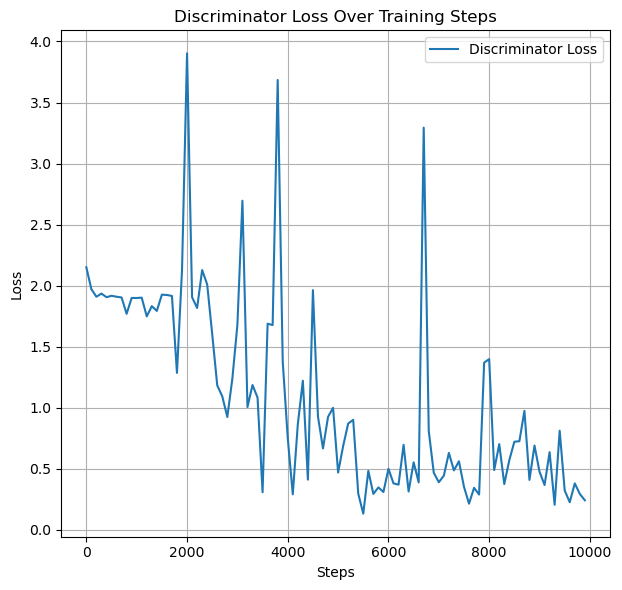

In [35]:
plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.plot(range(0, len(d_loss_history) * 100, 100), d_loss_history, label='Discriminator Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Discriminator Loss Over Training Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

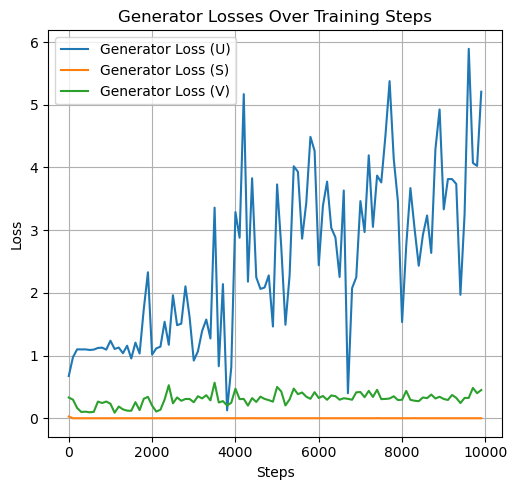

In [36]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 2)
plt.plot(range(0, len(g_loss_u_history) * 100, 100), g_loss_u_history, label='Generator Loss (U)')
plt.plot(range(0, len(g_loss_s_history) * 100, 100), g_loss_s_history, label='Generator Loss (S)')
plt.plot(range(0, len(g_loss_v_history) * 100, 100), g_loss_v_history, label='Generator Loss (V)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Generator Losses Over Training Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Generate Synthetic Data

In [37]:
generated_data = []
for i in range(int(n_windows / batch_size)):
    Z_ = next(random_series)
    d = synthetic_data(Z_)
    generated_data.append(d)

In [38]:
generated_data = np.array(np.vstack(generated_data))
generated_data.shape

(96, 48, 13)

In [39]:
# Rescale

generated_data = (scaler.inverse_transform(generated_data
                                           .reshape(-1, n_seq))
                  .reshape(-1, seq_len, n_seq))
generated_data.shape

(96, 48, 13)

In [40]:
print(generated_data[0])

[[-8.89797390e-01 -6.56501949e-01 -4.58247215e-01 -2.28434354e-01
  -1.62334549e+00 -1.48144972e+00  3.73272586e+00 -2.32545614e-01
  -6.21437192e-01 -5.43752670e-01 -9.19062197e-01 -3.04136425e-01
  -5.91476500e-01]
 [-8.37295890e-01 -6.25308692e-01 -8.61483574e-01 -6.74463093e-01
  -1.92818511e+00 -1.36627007e+00  3.85109568e+00 -1.38170600e-01
  -1.16854501e+00 -6.65025890e-01 -1.08795285e+00 -2.19134584e-01
  -6.66418731e-01]
 [-6.46996677e-01 -5.44362247e-01 -6.20360076e-01 -3.94784123e-01
  -1.58616567e+00 -1.18188536e+00  3.77501488e+00 -1.11011878e-01
  -8.19782495e-01 -5.99212170e-01 -1.04038966e+00 -4.21354651e-01
  -6.11631632e-01]
 [-6.37802184e-01 -8.99017394e-01 -9.67997789e-01 -9.20520961e-01
  -1.76644266e+00 -1.52873480e+00  3.75752640e+00 -2.57482260e-01
  -1.39818573e+00 -4.45258051e-01 -1.03624630e+00 -4.27600205e-01
  -7.67062008e-01]
 [-9.46860433e-01 -7.60591030e-01 -7.15029001e-01 -7.00659096e-01
  -2.06685209e+00 -1.43336570e+00  3.96412468e+00 -1.37396291e-01


### Plot sample Series

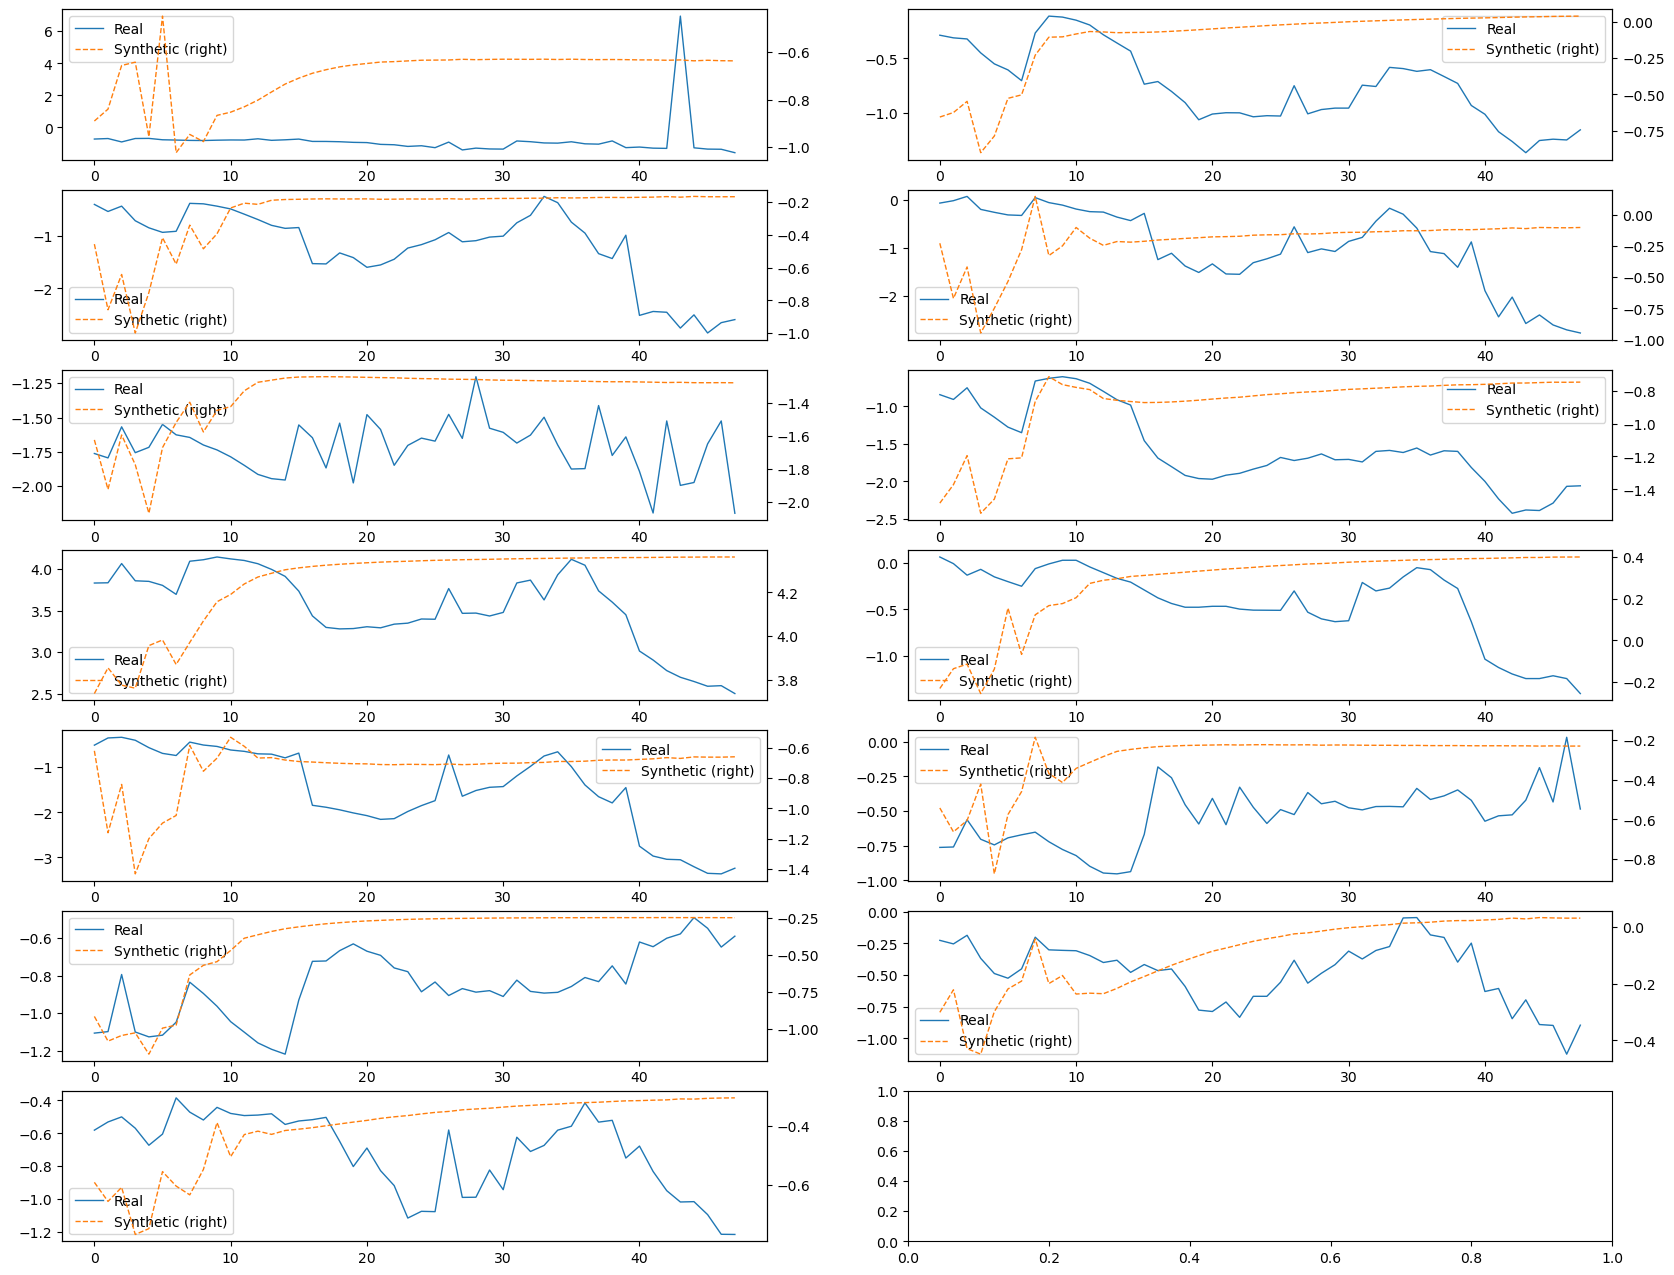

In [41]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(20, 16))
axes = axes.flatten()

synthetic = generated_data[np.random.randint(n_windows)]

idx = np.random.randint(len(df) - seq_len)
real = df.iloc[idx: idx + seq_len]

tickers = {1: 85750.0, 2: 292800000000000.0, 3: 8761305.0, 4: 8761955.0, 5: 300722000000000.0,
                6: 85670.0, 7: 7380249.0, 8: 7374527.0, 9: 7374526.0, 10: 73745258.0, 11: 73745257.0, 
                12: 301001000000000.0, 13: 291929000000000.0}

for j, ticker in enumerate(tickers):
    (pd.DataFrame({'Real': real.iloc[:, j].values,
                   'Synthetic': synthetic[:, j]})
     .plot(ax=axes[j],
           secondary_y='Synthetic', style=['-', '--'],
           lw=1))
